<a href="https://colab.research.google.com/github/wylerok-ux/My-work/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate_homework
events = pd.read_csv("events.csv")
print(f"\nEvets info")
events.info()
print(f"\nEvets head")
display(events.head())



Mounted at /content/drive
/content/drive/MyDrive/Mate_homework

Evets info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

Evets head


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


Витягуємо таблички і аналізуємо дані якого вони формату і що потрібно зробити.

In [ ]:
products = pd.read_csv("products.csv")
products.info()
display(products.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
countres = pd.read_csv("countries.csv")
countres.info()
countres.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


При перегляді даних ми бачимо що потрібно перетворити стовпці order_date і ship_date в відповідний формат datetime64[ns]. Знаходимо ключі для поєднання табличок разом: для першої таблички це product_id та id, для другої це country_code та 	alpha-3 використавши спосіб left join. Для полегшення роботи з табличкою то заголовки перетворю під стандарт Snake_case.

In [ ]:
events.columns = events.columns.str.lower().str.replace(' ', '_')
df = pd.merge(events, products, left_on= 'product_id', right_on= 'id',  how='left')
df = pd.merge(df,countres,left_on="country_code", right_on= 'alpha-3', how='left')
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


Тепер я перетворю корлонки що містять дату в відповідний формат datetime64[ns]

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1248 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
 10  id              1330 non-null   int64         
 11  item_type       1330 non-null   object        
 12  name            1248 non-null   object        
 13  alpha-2         1248 non-null   object        
 14  alpha-3         1248 non-null   object        
 15  regi

Перевіряю дані таблички на пропущені значення NaN де видно що в колонках units_sold пропущено 2, а в contry_code, name, alpha-2, alpha-3, region, sub-region маємо пропущених по 82 . Потім провожу аналіз пропущених значень в колонці contry_code замінити на пропущені median значення що не вплине на результат хоча можна було і усунути. Всі колонки з інформцією про країни що містять відсутні дані в кількості 82 (6.2%) від всього датасету то прийняв рішення на заміну їх значення на Other.

In [ ]:
df_mising_count = df.isna().sum()
df_mising_perc = (df.isna().sum() / df.shape[0] * 100).round(2)
df_mising = pd.concat([df_mising_count, df_mising_perc], axis=1)
df_mising.columns = ['count', '%']
df_mising.sort_values(by='count', ascending=False)

,count,%
country_code,82,6.17
alpha-2,82,6.17
alpha-3,82,6.17
region,82,6.17
sub-region,82,6.17
name,82,6.17
units_sold,2,0.15
order_id,0,0.00
ship_date,0,0.00
unit_price,0,0.00


In [ ]:
df['units_sold'] = df['units_sold'].fillna(df['units_sold'].median())
df = df.fillna('Other')
df.duplicated().sum()

np.int64(0)

Перевіряємо на аномалії датасет при використані discribe() При перевірці якихось аномалій не виявлено.

In [ ]:
df.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost,id
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.216541,264.893541,187.246812,5788.096241
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000,1270.000000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000,3127.000000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000,5988.000000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000,8681.000000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000,8969.000000
std,2.573882e+08,NaN,NaN,2820.728878,2903.012194,217.323460,176.158873,2820.728878


Видалимо не потрібні стовпці де ми їх не використаємо для аналізу це alpha-2, alpha-3.

In [ ]:
df = df.drop(columns=['alpha-2', 'alpha-3'])
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Other,7940,Online,4693.0,668.27,502.54,7940,Household,Other,Other,Other
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,Europe,Southern Europe


In [ ]:
df["total_revenue"] = df["units_sold"] * df["unit_price"]  # Загальний дохід
df["total_cost"] = df["units_sold"] * df["unit_cost"]        # Загальні витрати
df["total_profit"] = df["total_revenue"] - df["total_cost"]  # Чистий прибуток
df["delivery_time"] = (df["ship_date"] - df["order_date"]).dt.days  # Швидкість доставки в днях
df.head()



,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,region,sub-region,total_revenue,total_cost,total_profit,delivery_time
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,M,Other,7940,Online,4693.0,668.27,502.54,7940,Household,Other,Other,Other,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38


In [ ]:
print(f"Total orders = {df['order_id'].count()}")
print(f"Total profit = {df['total_profit'].sum().round(2)}$")
print(f"Total units sold = {df['units_sold'].sum()}")
print(f"Total revenue = {df['total_revenue'].sum().round(2)}$")
print(f"Total cost = {df['total_cost'].sum().round(2)}$")

Total orders = 1330
Total profit = 501842633.12$
Total units sold = 6586448.0
Total revenue = 1704628370.65$
Total cost = 1202785737.53$


In [ ]:
list_country = pd.DataFrame(df[df['name'] != 'Other']['name'].unique(), columns=['Country'])
list_region = pd.DataFrame(df[df['region'] != 'Other']['region'].unique(), columns=['Region'])
list_subregion = pd.DataFrame(df[df['sub-region'] != 'Other']['sub-region'].unique(), columns=['Sub-region'])
geo_table = pd.concat([list_country['Country'], list_region['Region'], list_subregion['Sub-region']], axis=1)
geo_table = geo_table.replace('Other', ' ')
geo_table = geo_table.fillna('')

print(geo_table)

                   Country  Region       Sub-region
0                   Norway  Europe  Northern Europe
1                   Serbia    Asia  Southern Europe
2               Montenegro           Eastern Europe
3                 Slovakia           Western Europe
4                   France             Western Asia
5                    Spain                         
6                  Croatia                         
7                  Germany                         
8                  Armenia                         
9                  Georgia                         
10          United Kingdom                         
11                Slovenia                         
12                 Romania                         
13                  Poland                         
14              Luxembourg                         
15                  Cyprus                         
16                 Belgium                         
17               Lithuania                         
18          

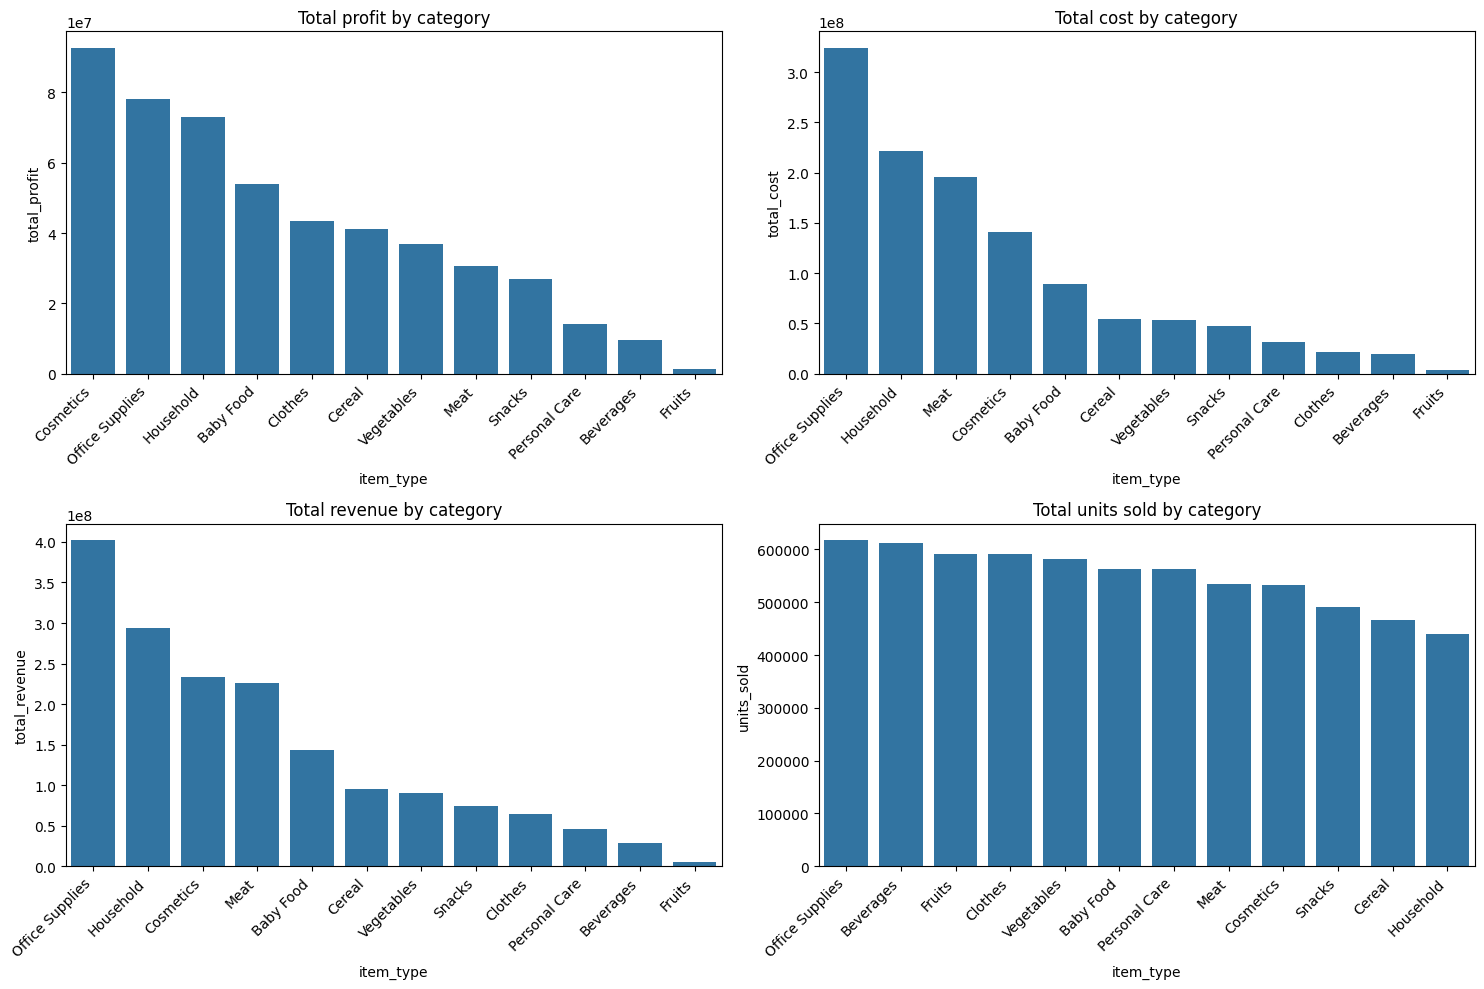

In [ ]:
order_1 = df.groupby('item_type')['total_profit'].sum().sort_values(ascending=False).index
order_2 = df.groupby('item_type')['total_cost'].sum().sort_values(ascending=False).index
order_3 = df.groupby('item_type')['total_revenue'].sum().sort_values(ascending=False).index
order_4 = df.groupby('item_type')['units_sold'].sum().sort_values(ascending=False).index
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
sns.barplot(data=df, x='item_type', y='total_profit', ax=ax[0, 0], estimator='sum', errorbar= None, order= order_1)
sns.barplot(data=df,x='item_type', y='total_cost', ax=ax[0, 1], estimator='sum', errorbar= None, order= order_2)
sns.barplot(data=df,x='item_type', y='total_revenue', ax=ax[1, 0], estimator='sum', errorbar= None, order= order_3)
sns.barplot(data=df,x='item_type', y='units_sold', ax=ax[1, 1], estimator='sum', errorbar= None, order= order_4)
ax[0, 0].set_title('Total profit by category')
ax[0, 1].set_title('Total cost by category')
ax[1, 0].set_title('Total revenue by category')
ax[1, 1].set_title('Total units sold by category')
for single_ax in ax.flatten():
    for label in single_ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()





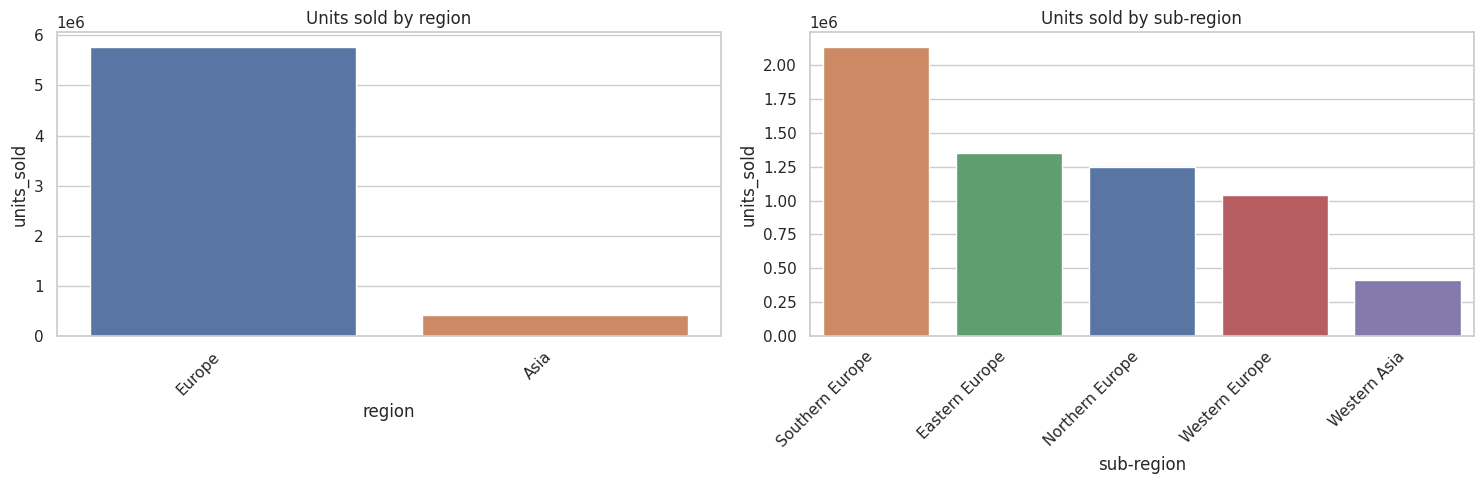

=== Top 5 ===
   Country  units_sold
 Macedonia    203078.0
San Marino    192228.0
   Andorra    185686.0
    Greece    176859.0
     Malta    173641.0


In [ ]:
df_map = df.groupby(['country_code', 'name'])['units_sold'].sum().reset_index()
df_map['country_code'] = df_map['country_code'].str.upper()
fig = px.choropleth(data_frame=df_map, locations="country_code", color="units_sold", hover_name="name", color_continuous_scale=px.colors.sequential.Plasma, title="Sales by country")
#fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()
# 1. Створюємо полотно для графіків
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# 2. Фільтруємо дані для підрегіонів та знаходимо правильний порядок сортування (за спаданням суми)
sub_region_filtered = df[df['sub-region'] != 'Other']
sub_region_order = (sub_region_filtered
                    .groupby('sub-region')['units_sold']
                    .sum()
                    .sort_values(ascending=False)
                    .index)

# Додатково можна зробити те саме для звичайних регіонів, щоб обидва графіки були красивими
region_filtered = df[df['region'] != 'Other']
region_order = (region_filtered
                .groupby('region')['units_sold']
                .sum()
                .sort_values(ascending=False)
                .index)

# 3. Перший графік: Регіони (теж додано сортування та hue)
sns.barplot(
    data=region_filtered,
    x='region',
    y='units_sold',
    estimator='sum',
    errorbar=None,
    ax=ax[0],
    order=region_order,    # Сортування
    hue='region',
    legend=False
)
ax[0].set_title('Units sold by region')

# 4. Другий графік: Підрегіони із ДОДАНИМ сортуванням
sns.barplot(
    data=sub_region_filtered,
    x='sub-region',
    y='units_sold',
    estimator='sum',
    errorbar=None,
    ax=ax[1],
    order=sub_region_order, # Сортування за спаданням суми
    hue='sub-region',
    legend=False
)
ax[1].set_title('Units sold by sub-region')

# 5. Поворот підписів осі X для обох графіків
for single_ax in ax.flatten():
    for label in single_ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

plt.tight_layout()
plt.show()
print("=== Top 5 ===")
df_top_5 = df[df['name'] != 'Other'].groupby('name')['units_sold'].sum().sort_values(ascending=False).head(5).reset_index().rename(columns={'name': 'Country'})
print(df_top_5.to_string(index=False))

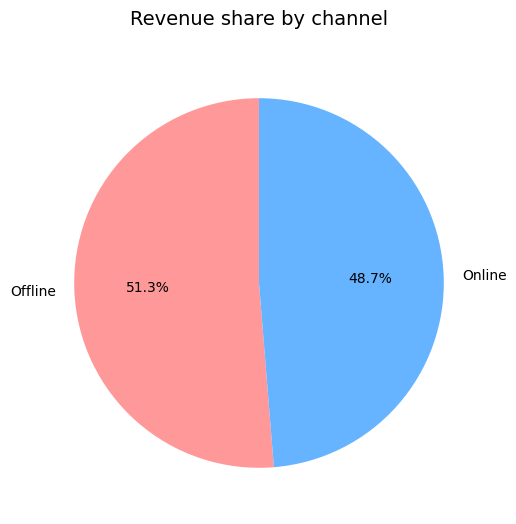

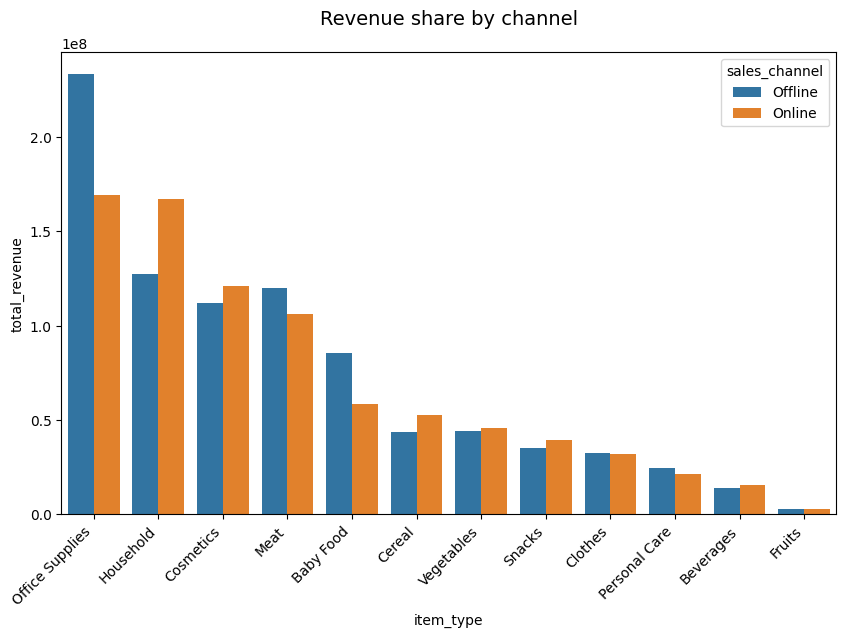

In [ ]:
df['sales_channel'] = df['sales_channel'].str.capitalize()
df_pie = df.groupby('sales_channel')['total_revenue'].sum()
plt.figure(figsize=(6, 6))
plt.pie(df_pie, labels=df_pie.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Revenue share by channel', fontsize=14, pad=20)
plt.show()
df_chanel = df.groupby(['sales_channel', 'item_type'])['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_chanel, x='item_type', y='total_revenue', hue='sales_channel')
plt.title('Revenue share by channel', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()



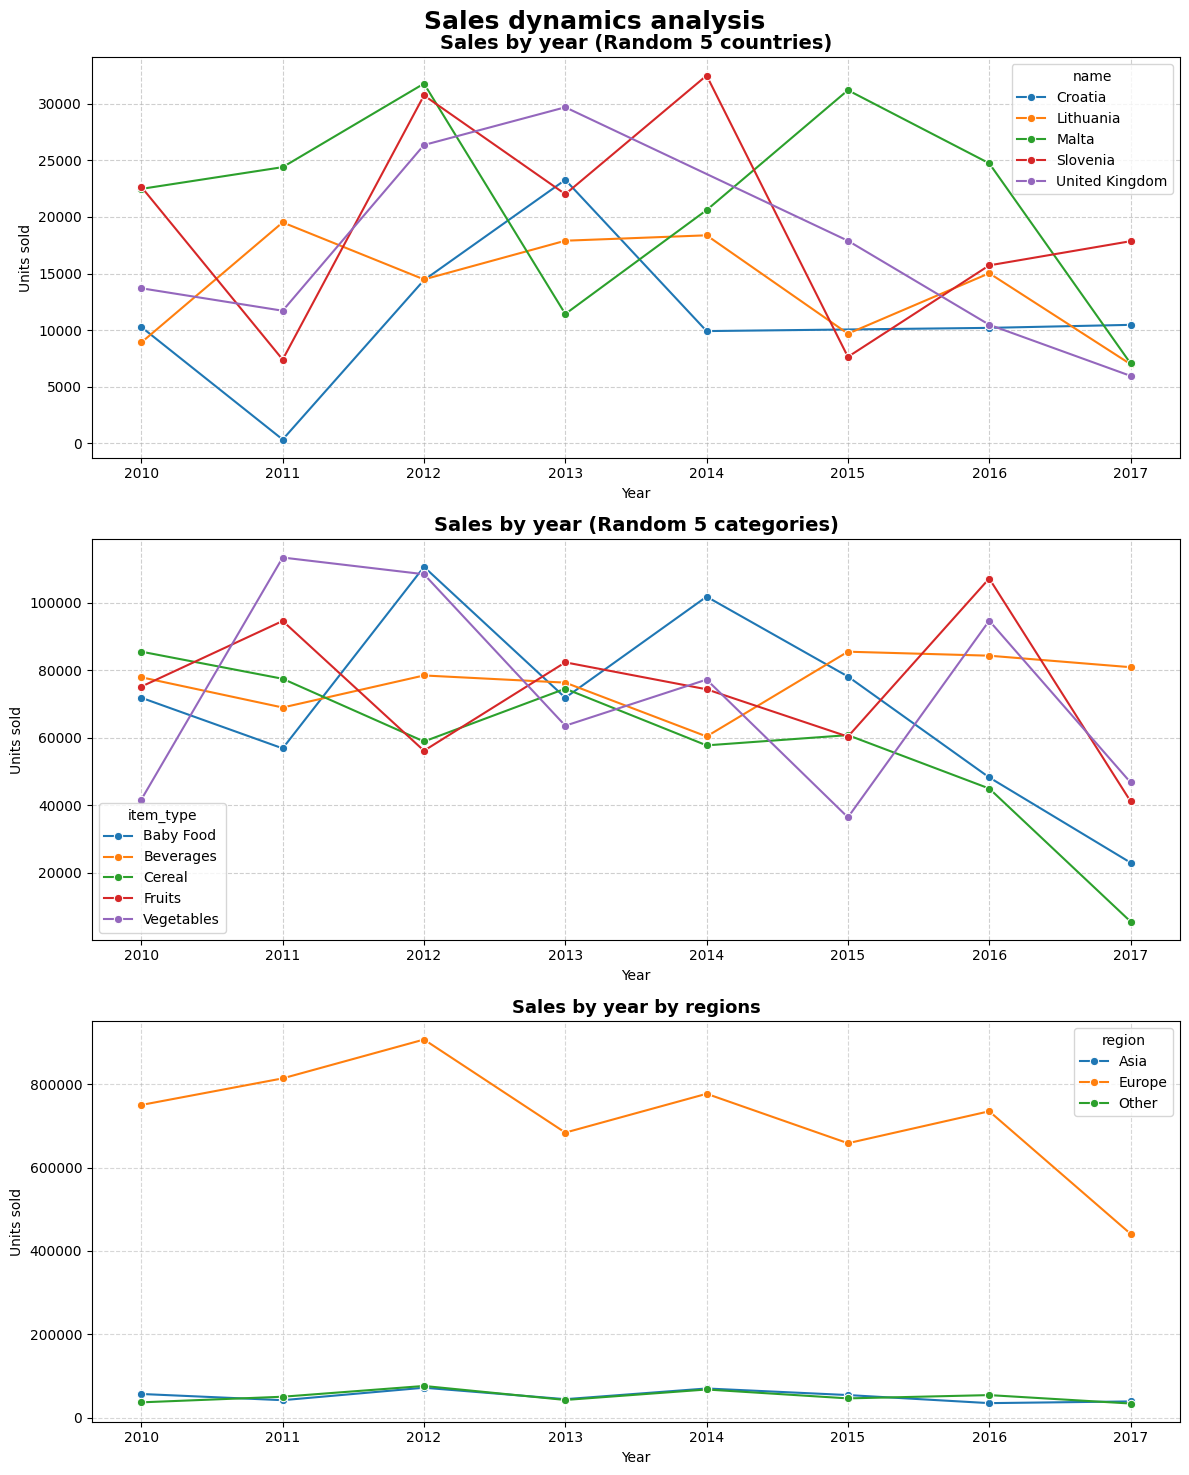

In [ ]:
# Дані для країн
sold_year_by_country = df.groupby([df['order_date'].dt.year, 'name'])['units_sold'].sum().reset_index()
random_countries = df['name'].drop_duplicates().sample(5).tolist()
df_filtered_countries = sold_year_by_country[sold_year_by_country['name'].isin(random_countries)]

# Дані для категорій (item_type)
sold_year_by_category = df.groupby([df['order_date'].dt.year, 'item_type'])['units_sold'].sum().reset_index()
random_category = df['item_type'].drop_duplicates().sample(5).tolist()
df_filtered_categories = sold_year_by_category[sold_year_by_category['item_type'].isin(random_category)]

# В. Дані для регіонів (Беремо всі доступні регіони, бо їх зазвичай небагато)
df_filtered_regions = df.groupby([df['order_date'].dt.year, 'region'])['units_sold'].sum().reset_index()

# ==========================================
# 2. СТВОРЕННЯ СІТКИ ГРАФІКІВ (Subplots)
# ==========================================

# Створюємо фігуру з 2 рядків і 1 стовпчика (nrows=2, ncols=1)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15))

# --- Графік 1: Країни (Верхній, index 0) ---
sns.lineplot(
    data=df_filtered_countries,
    x='order_date',
    y='units_sold',
    hue='name',
    marker='o',
    ax=axes[0]  # Вказуємо, що малюємо на першому графіку
)
axes[0].set_title('Sales by year (Random 5 countries)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Units sold')
axes[0].grid(True, linestyle='--', alpha=0.6) # додаємо легку сітку

# --- Графік 2: Категорії (Нижній, index 1) ---
sns.lineplot(
    data=df_filtered_categories,
    x='order_date',
    y='units_sold',
    hue='item_type',
    marker='o',
    ax=axes[1]  # Вказуємо, що малюємо на другому графіку
)
axes[1].set_title('Sales by year (Random 5 categories)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Units sold')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Графік 3: Регіони (Нижній, index 2) ---
sns.lineplot(
    data=df_filtered_regions, x='order_date', y='units_sold', hue='region', marker='o', ax=axes[2]
)
axes[2].set_title('Sales by year by regions', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Units sold')
axes[2].grid(True, linestyle='--', alpha=0.5)
# ==========================================
# 3. ФІНАЛЬНЕ ОФОРМЛЕННЯ
# ==========================================

# Загальний великий заголовок для всього вікна
fig.suptitle('Sales dynamics analysis', fontsize=18, fontweight='bold', y=0.98)

# Автоматично підганяємо відстані між графіками, щоб написи не перекривалися
plt.tight_layout()

# Показуємо поєднаний графік
plt.show()

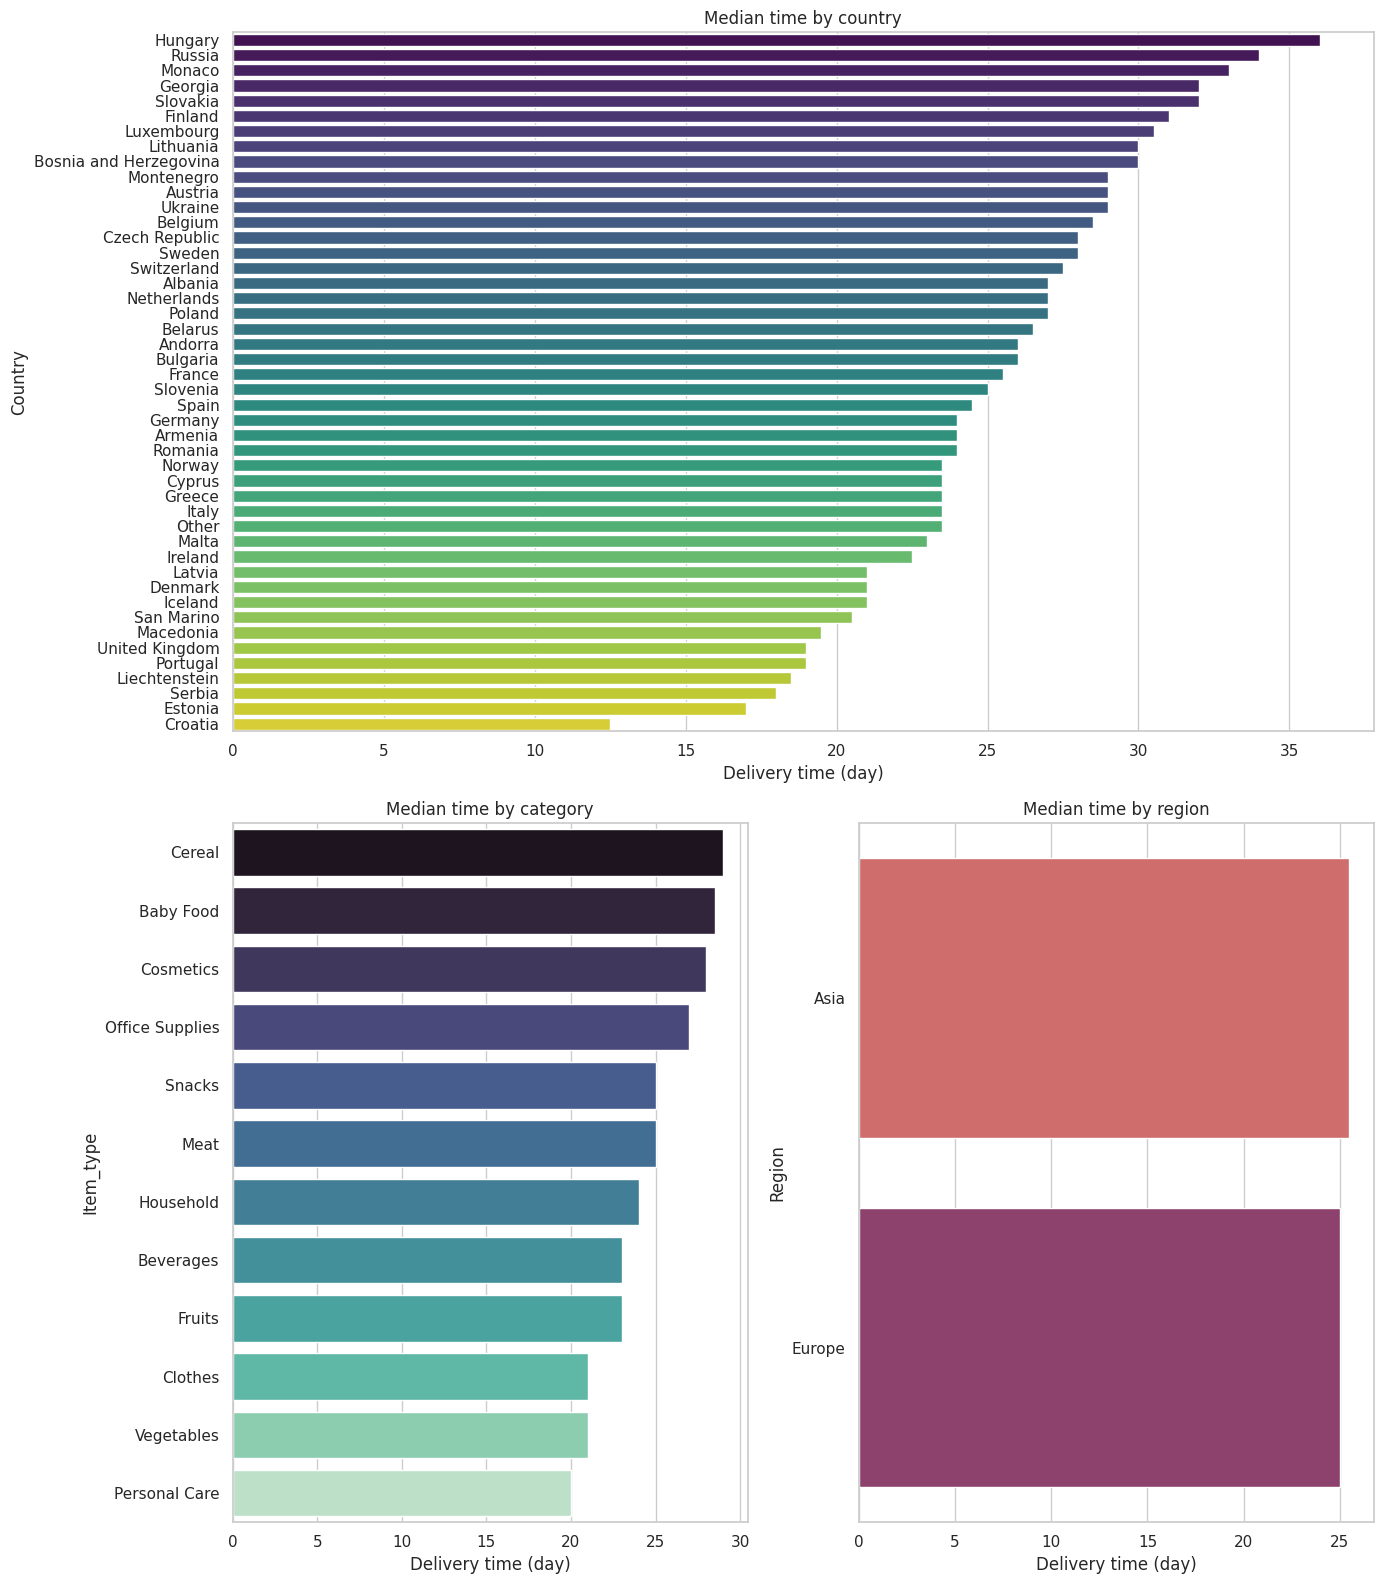

In [ ]:
# 1. Агрегація з одночасним сортуванням за спаданням часу доставки
df_median_delivery = (df.groupby('name')['delivery_time']
                      .median()
                      .reset_index()
                      .sort_values(by='delivery_time', ascending=False))

df_median_delivery1 = (df.groupby('item_type')['delivery_time']
                       .median()
                       .reset_index()
                       .sort_values(by='delivery_time', ascending=False))

df_median_delivery2 = (df.groupby('region')['delivery_time']
                       .median()
                       .reset_index()
                       .sort_values(by='delivery_time', ascending=False)
                       .query("region not in ['Other']"))

# --- РІШЕННЯ ПРОБЛЕМИ З ПУСТИМИ СІТКАМИ ---
# Створюємо ЛИШЕ чисте полотно (фігуру), без дефолтних графіків subplots
fig = plt.figure(figsize=(14, 16))
sns.set_theme(style="whitegrid")

# Створюємо сітку GridSpec 2х2 на цій фігурі
gs = fig.add_gridspec(2, 2)

# Нарізаємо осі безпосередньо із сітки gs
ax_top = fig.add_subplot(gs[0, :])          # Весь перший рядок
ax_bottom_left = fig.add_subplot(gs[1, 0])  # Другий рядок, ліва колонка
ax_bottom_right = fig.add_subplot(gs[1, 1]) # Другий рядок, права колонка

# --- Верхній графік (Займає весь перший рядок) ---
sns.barplot(ax=ax_top, x='delivery_time', y='name', data=df_median_delivery, palette='viridis', hue='name', legend=False)


ax_top.set_title('Median time by country')
ax_top.set_xlabel('Delivery time (day)')
ax_top.set_ylabel('Country')

# --- Нижній лівий графік ---
sns.barplot(ax=ax_bottom_left, x='delivery_time', y='item_type', data=df_median_delivery1, palette='mako', hue='item_type', legend=False)

ax_bottom_left.set_title('Median time by category')
ax_bottom_left.set_xlabel('Delivery time (day)')
ax_bottom_left.set_ylabel('Item_type')

# --- Нижній правий графік ---
sns.barplot(ax=ax_bottom_right, x='delivery_time', y='region', data=df_median_delivery2, palette='flare', hue='region', legend=False)

ax_bottom_right.set_title('Median time by region')
ax_bottom_right.set_xlabel('Delivery time (day)')
ax_bottom_right.set_ylabel('Region')

# Коригуємо відступи
plt.tight_layout()
plt.show()

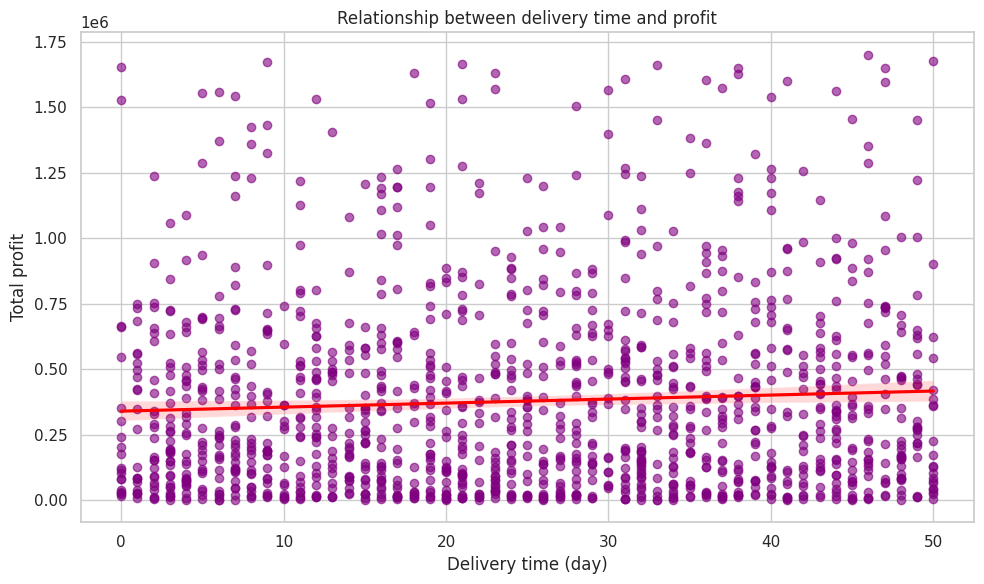

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Малюємо точки та додаємо лінію тренду (regplot / lmplot)
sns.regplot(
    data=df,
    x='delivery_time',
    y='total_profit',
    scatter_kws={'alpha':0.6, 'color': 'purple'},
    line_kws={'color': 'red'}
)

plt.title('Relationship between delivery time and profit')
plt.xlabel('Delivery time (day)')
plt.ylabel('Total profit')

plt.tight_layout()
plt.show()

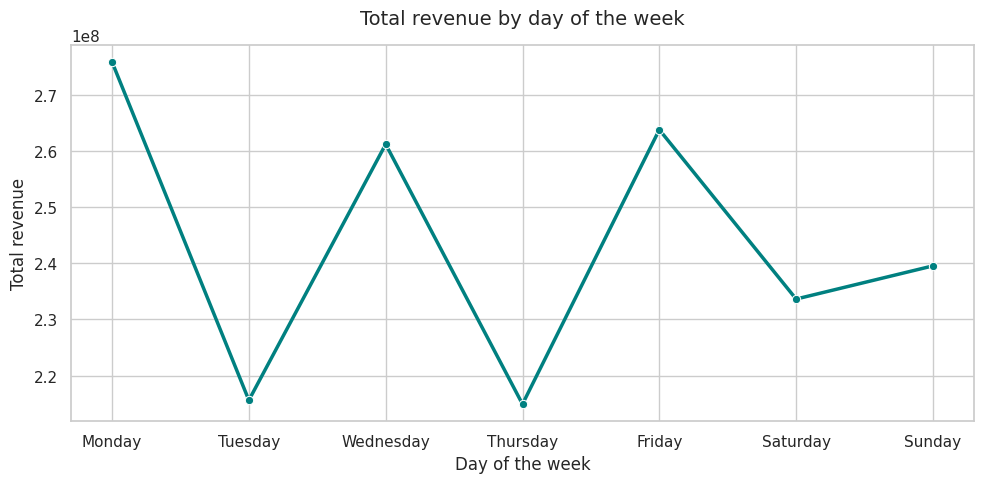

In [ ]:
df['day_of_week'] = df['order_date'].dt.day_name()

# 3. Групуємо за днями тижня та рахуємо сумарний виторг
df_revenue_by_day = (df.groupby('day_of_week')['total_revenue']
                     .sum()  # або .mean() для середнього виторгу
                     .reset_index())

# 4. ВАЖЛИВО: Сортуємо дні тижня хронологічно, а не за алфавітом
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_revenue_by_day['day_of_week'] = pd.Categorical(df_revenue_by_day['day_of_week'], categories=days_order, ordered=True)
df_revenue_by_day = df_revenue_by_day.sort_values('day_of_week')

# 5. Побудова лінійного графіка
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Будуємо лінію з маркерами на кожному дні
sns.lineplot(
    data=df_revenue_by_day,
    x='day_of_week',
    y='total_revenue',
    marker='o',         # додає точки на графік
    linewidth=2.5,      # товщина лінії
    color='teal'        # колір лінії
)

# Налаштування підписів та оформлення
plt.title('Total revenue by day of the week', fontsize=14, pad=15)
plt.xlabel('Day of the week', fontsize=12)
plt.ylabel('Total revenue', fontsize=12)

# Робимо так, щоб графік виглядав охайно
plt.tight_layout()
plt.show()

## **Детальний** **звіт**
Дана фірма під час свого існування опрацювала 1330 замовлень з яких отримала прибуток в сумі 501842633.12\$ і з відповідними затратами 1202785737.53\$  що охопили 45 країн. Діяльність відбувається в Європі і Азії.Найбільшою популярністю користуються канцелярські товари але більший прибуток принесли товари косметики в сумі 88010907.56\$. Популярностю зовсім не користуються фрукти що принесли прибуток в сумі 1280035.35\$.
Основна діяльність компанії відбувається в Європі що показує 5761244 кількість проданих товарів відносно Азії в 410427 проданих. По субрегіонам лідирує Південна Європа 2126353 з кількістю продаж в якій лідирує Македонія з 203078 продаж.
Канали продажів якусь різницю не мають що  можна сказати 50/50 відповідних продаж.
В динаміці продаж за місяцями і роками спостерігається така тенденція що в 2012, 2014, 2016 були кращі продажі  по Європі де найкращий рік то 2012 з 907956 кількістю продаж. В Азії то якихось великої змінності не відбувається що проходять в районі 50 тис до 70тис.  По місяцях видно що на початку року найкращі продажі і потім до кінця року спадають.
При аналізі часу доставки і прибутку не спостерігається жадної тенденції де видно що час доставки  не впливає на прибуток
